In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Načtení dat ze souboru CSV v podadresáři 'data'
data = pd.read_csv('data/world_bank_indicators.csv')
data_test=pd.read_csv('data/test_data.csv')
# Shrnutí dat a seznam názvů sloupců
print("Souhrn dat:")
print(data.describe())
print("\nSeznam názvů sloupců:")
print(list(data.columns))



Souhrn dat:
               year  Access to electricity (% of population)  \
count  16960.000000                              7611.000000   
mean    1991.500000                                81.045979   
std       18.473498                                28.546144   
min     1960.000000                                 0.533899   
25%     1975.750000                                69.653940   
50%     1991.500000                                98.400000   
75%     2007.250000                               100.000000   
max     2023.000000                               100.000000   

       Adjusted net savings, including particulate emission damage (% of GNI)  \
count                                        5429.000000                        
mean                                            7.793301                        
std                                            11.557922                        
min                                          -166.127193                        
25%   

In [2]:
from definitions import FuzzyRelations
from definitions import models
from definitions import models as md
from definitions import quantifiers
import numpy as np
import openpyxl

from importlib import reload  # Python 3.4+
FuzzyRelations = reload(FuzzyRelations)
models = reload(models)
quantifiers = reload(quantifiers)
X = data['GDP per capita (current US$)']
Y = data['Fertility rate, total (births per woman)']
X_test = data_test['GDP per capita (current US$)']
Y_test = data_test['Fertility rate, total (births per woman)']

# Remove NaN rows
mask = pd.notnull(X) & pd.notnull(Y)
mask_test = pd.notnull(X_test) & pd.notnull(Y_test)
X = X[mask]
Y = Y[mask]
X_test = X_test[mask_test]
Y_test = Y_test[mask_test]

# Union of values (unique elements from both arrays)
Y_union = np.union1d(Y, Y_test)

# Compute min and max
y_min = np.min(Y_union)
y_max = np.max(Y_union)

print("Union size:", Y_union.shape[0])
print("y_min:", y_min)
print("y_max:", y_max)

Union size: 7640
y_min: 0.701
y_max: 8.606


## Load and Plot the Model

In [3]:
import pickle

with open("models/model10Rules_training_WorldBank_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
print(loaded_model["quantifier"])
print(loaded_model["nodesx"])
print(loaded_model.keys()) 
# Předpokládáme, že nodesyL a nodesyR jsou stejně dlouhé seznamy čísel
quant=loaded_model["quantifier"]
nodesyL = loaded_model["nodesyL"]
nodesyR = loaded_model["nodesyR"]

# Výpočet průměru pro každý odpovídající prvek
averaged_y = [(l + r) / 2 for l, r in zip(nodesyL, nodesyR)]
# Výpočet průměru pro každý odpovídající prvek
diff_y = [r-l for l, r in zip(nodesyL, averaged_y)]

print(averaged_y)
print(diff_y)

[0.75, 0.78, 0.92, 0.93, 0.95, 0.96, 0.97, 0.98, 0.99, 0.99]
[11.8013216739, 19688.994130965806, 39366.186940257714, 59043.37974954962, 78720.57255884154, 98397.76536813345, 118074.95817742535, 137752.15098671726, 157429.34379600917, 177106.53660530108, 196784.729414593]
dict_keys(['ModelQuantifiedRules', 'nodesx', 'nodesyL', 'nodesyR', 'x', 'y', 'quantifier', 'maxx', 'minx', 'maxfx', 'minfx', 'decl', 'dx'])
[3.983288782317455, 3.4758548678606402, 1.8890308307388175, 1.7764074694507315, 1.682791854281427, 1.5790385147612016, 1.5335946559796052, 1.4817439455180528, 1.5052886808954853, 1.5083273385814235]
[1.7086613364586398, 1.6568464601022248, 0.4465572465696057, 0.3132658008374807, 0.234186356649426, 0.1859502944520668, 0.16719538088681696, 0.10846965777528306, 0.07746477661234286, 0.0676600534316043]


## Test the Model's Precision

In [24]:
models = reload(models)


Characteristics 5 rules

In [19]:
with open("models/model5Rules_training_WorldBank_model.pkl", "rb") as f:
    loaded_model5 = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model5,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="MOM"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])

Predikce: [3.896882673447149, 3.896882673447149, 2.0204142753359973, 2.501375953505267, 3.896882673447149, 3.896882673447149, 2.896195241554668, 3.896882673447149, 3.896882673447149, 3.896882673447149, 3.222100617508173, 3.896882673447149, 3.896882673447149, 3.896882673447149, 3.896882673447149, 3.896882673447149, 3.896882673447149, 3.896882673447149, 2.732524700326916, 3.2149220849981845, 2.0103643298220124, 3.896882673447149, 3.896882673447149, 3.088579912822376, 3.896882673447149, 3.896882673447149, 3.1187297493643302, 2.9694162731565568, 3.0986298583363605, 3.0498158372684343, 3.1876436614602253, 3.896882673447149, 3.140265346894297, 3.1488795859062844, 3.896882673447149, 3.226407737014166, 3.223536324010171, 3.896882673447149, 3.896882673447149, 3.1689794769342536, 3.1015012713403562, 3.896882673447149, 3.896882673447149, 3.1531867054122773, 3.896882673447149, 3.1933864874682163, 3.1517509989102797, 3.896882673447149, 3.896882673447149, 3.125908281874319, 3.019666000726481, 3.8968

Characteristics for 10 rules

In [ ]:
with open("models/model10Rules_training_WorldBank_model.pkl", "rb") as f:
    loaded_model10 = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model10,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="MOM"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])


Predikce: [3.984460770069015, 3.984460770069015, 1.7763441699963678, 2.0247213948419907, 3.984460770069015, 3.984460770069015, 2.6262824191790775, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 2.310426988739557, 3.984460770069015, 1.7763441699963678, 3.984460770069015, 3.984460770069015, 2.818667090446785, 3.984460770069015, 3.984460770069015, 3.918418270977116, 2.6995034507809663, 2.827281329458773, 2.7799030148928443, 3.984460770069015, 3.984460770069015, 3.939953868507084, 3.94856810751907, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.984460770069015, 3.9672322920450416, 2.831588448964766, 3.984460770069015, 3.984460770069015, 3.951439520523066, 3.984460770069015, 3.984460770069015, 3.9500038140210685, 3.984460770069015, 3.984460770069015, 3.9255968034871045, 2.74975317835089, 3.98446077006

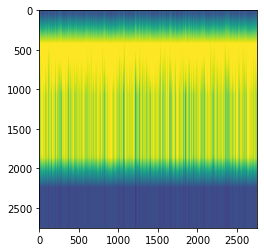

In [10]:
plt.imshow(values)


Characteristics 20 rules

In [17]:
with open("models/model20Rules_training_WorldBank_model.pkl", "rb") as f:
    loaded_model20 = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model20,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="MOM"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])


Predikce: [3.931339629495096, 3.911239738467127, 1.7706013439883763, 1.892636396658191, 3.921289683981112, 4.107931529240829, 2.3865194333454416, 4.107931529240829, 4.107931529240829, 4.107931529240829, 3.8652971304031967, 3.9083683254631314, 4.107931529240829, 3.93564674900109, 3.9198539774791135, 3.9370824555030874, 3.941389575009081, 4.107931529240829, 2.0720997094079188, 3.858118597893208, 1.7706013439883763, 3.9399538685070836, 4.107931529240829, 2.732524700326916, 3.9083683254631314, 3.931339629495096, 2.772724482382855, 2.494197420995278, 2.752624591354886, 2.654996549219034, 3.8308401743552487, 4.107931529240829, 2.79569578641482, 2.8043100254268074, 4.107931529240829, 3.8696042499091905, 3.8667328369051943, 3.883961314929168, 3.9385181620050855, 3.8121759898292775, 2.755496004358881, 3.9270325099891026, 4.107931529240829, 3.7963832183073007, 3.9399538685070836, 3.8365830003632397, 2.8057457319288055, 3.90262549945514, 3.9098040319651295, 2.781338721394842, 2.5946968761351257, 

Characteristics 40 rules

In [18]:
with open("models/model40Rules_training_WorldBank_model.pkl", "rb") as f:
    loaded_model40 = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model40,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="MOM"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])

Predikce: [4.034710497638939, 4.016046313112969, 1.7792155830003633, 1.862486560116237, 4.0246605521249545, 4.194073919360698, 2.2415130766436615, 4.1926382128587, 4.049067562658917, 4.1969453323646935, 3.2077435524881945, 4.011739193606974, 4.194073919360698, 4.039017617144933, 4.0246605521249545, 4.041889030148929, 4.044760443152924, 4.0461961496549215, 1.981650199782056, 3.200565019978206, 1.7792155830003633, 4.043324736650926, 4.1969453323646935, 2.649253723211043, 4.011739193606974, 4.036146204140937, 2.709553396294951, 2.4109264438794042, 2.6664822012350164, 2.57172557210316, 3.154622411914276, 4.194073919360698, 2.752624591354886, 2.7698530693788594, 4.191202506356702, 3.2106149654921903, 3.209179258990193, 3.226407737014167, 4.041889030148929, 3.117294042862332, 2.6750964402470037, 4.030403378132946, 4.195509625862695, 2.778467308390846, 4.044760443152924, 3.1632366509262626, 2.775595895386851, 4.005996367598983, 4.014610606610971, 2.723910461314929, 2.5085544860152558, 4.19694

Characteristics for 40 rules with MaxofM

In [22]:
with open("models/model40Rules_training_WorldBank_model.pkl", "rb") as f:
    loaded_model40 = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model40,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="COG"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])

Predikce: [4.421887027572895, 4.410109038518906, 2.8443084724725183, 2.89974179467872, 4.415837416599451, 4.432618943181839, 3.3917648824411417, 4.431981945991788, 4.4298045155922425, 4.433378091470052, 4.367751307053645, 4.407734105742282, 4.432458684044985, 4.424649978180243, 4.415711539190161, 4.4256351004468755, 4.427759423738783, 4.428176175687916, 2.909095588776215, 4.359581999014739, 2.8443084724725183, 4.426951946340313, 4.433539259135524, 4.131199999451631, 4.407503339243145, 4.422511068399558, 4.203541157602348, 3.821136485263537, 4.14694219756135, 4.062469408205819, 4.315490677864099, 4.4324587188865054, 4.237698732476502, 4.251369899136948, 4.431717023754702, 4.371938184215084, 4.369529239745959, 4.389011913393364, 4.426189765926708, 4.284101369797141, 4.1587484538669415, 4.419500266656471, 4.432909785271013, 4.257136939437901, 4.427333660777486, 4.324521093903017, 4.2550615545979, 4.4037486320209815, 4.409304582445491, 4.21524506353396, 4.007432710479587, 4.433319210864887

Characteristics 50 rules

In [15]:
with open("models/model50Rules_training_WorldBank_model.pkl", "rb") as f:
    loaded_model50 = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model50,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="MOM"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])


Predikce: [3.995946422084998, 3.977282237559027, 1.782086996004359, 1.8581794406102434, 3.985896476571014, 4.1854596803487105, 2.237205957137668, 4.182588267344715, 4.176845441336724, 4.186895386850709, 3.2235363240101704, 3.972975118053033, 4.184023973846713, 4.168231202324737, 3.985896476571014, 4.169666908826735, 4.1739740283327285, 4.1739740283327285, 1.9672931347620777, 3.212050671994189, 1.782086996004359, 4.17253832183073, 4.188331093352707, 2.647818016709045, 3.972975118053033, 3.9973821285869957, 2.7081176897929535, 2.4094907373774066, 2.6650464947330184, 2.570289865601162, 3.1546224119142754, 4.184023973846713, 2.751188884852888, 2.7684173628768614, 4.182588267344715, 3.2321505630221576, 3.226407737014166, 3.2493790410461316, 4.171102615328732, 2.8071814384308027, 2.672225027243008, 3.9916393025790047, 4.1854596803487105, 2.775595895386851, 4.17253832183073, 3.166108063930258, 2.772724482382855, 3.967232292045042, 3.975846531057029, 2.7224747548129318, 2.507118779513258, 4.18

Characteristics 60 rules

In [16]:
with open("models/model50Rules_training_WorldBank_model.pkl", "rb") as f:
    loaded_model50 = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model50,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="MOM"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])


Predikce: [3.995946422084998, 3.977282237559027, 1.782086996004359, 1.8581794406102434, 3.985896476571014, 4.1854596803487105, 2.237205957137668, 4.182588267344715, 4.176845441336724, 4.186895386850709, 3.2235363240101704, 3.972975118053033, 4.184023973846713, 4.168231202324737, 3.985896476571014, 4.169666908826735, 4.1739740283327285, 4.1739740283327285, 1.9672931347620777, 3.212050671994189, 1.782086996004359, 4.17253832183073, 4.188331093352707, 2.647818016709045, 3.972975118053033, 3.9973821285869957, 2.7081176897929535, 2.4094907373774066, 2.6650464947330184, 2.570289865601162, 3.1546224119142754, 4.184023973846713, 2.751188884852888, 2.7684173628768614, 4.182588267344715, 3.2321505630221576, 3.226407737014166, 3.2493790410461316, 4.171102615328732, 2.8071814384308027, 2.672225027243008, 3.9916393025790047, 4.1854596803487105, 2.775595895386851, 4.17253832183073, 3.166108063930258, 2.772724482382855, 3.967232292045042, 3.975846531057029, 2.7224747548129318, 2.507118779513258, 4.18

In [ ]:
with open("100rules_model.pkl", "rb") as f:
    model100 = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=model100,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="COG"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])

NameError: name 'datax' is not defined